In [ ]:
import sys, os
sys.path.append(os.path.abspath('..'))

import joblib
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.config import SETTINGS
import src.preprocessing as pp

df = pp.load_data("../" + SETTINGS['paths']['raw_data'])
_, X_val, _, _, y_val, _ = pp.split_time_chronological(
    df, train_size=SETTINGS['train_params']['train_size'], val_size=SETTINGS['train_params']['val_size']
)

pipeline = joblib.load("../" + SETTINGS['paths']['model_output'])
preprocessor = pipeline.named_steps['preprocessor']
xgb_model = pipeline.named_steps['classifier']

X_val_scaled = preprocessor.transform(X_val)

clean_names = [name.split('__')[-1] for name in preprocessor.get_feature_names_out()]

X_val_df = pd.DataFrame(X_val_scaled, columns=clean_names, index=X_val.index)

print("Data is scaled and ready for SHAP!")

Data is scaled and ready for SHAP!


In [ ]:
fraud_cases = y_val[y_val == 1].index

normal_cases = y_val[y_val == 0].sample(900, random_state=42).index

small_sample_index = fraud_cases.union(normal_cases)
X_sample = X_val_df.loc[small_sample_index]
y_sample = y_val.loc[small_sample_index]

explainer = shap.Explainer(xgb_model, X_sample)
shap_values = explainer(X_sample)

print("SHAP math is done! Ready to plot.")

SHAP math is done! Ready to plot.


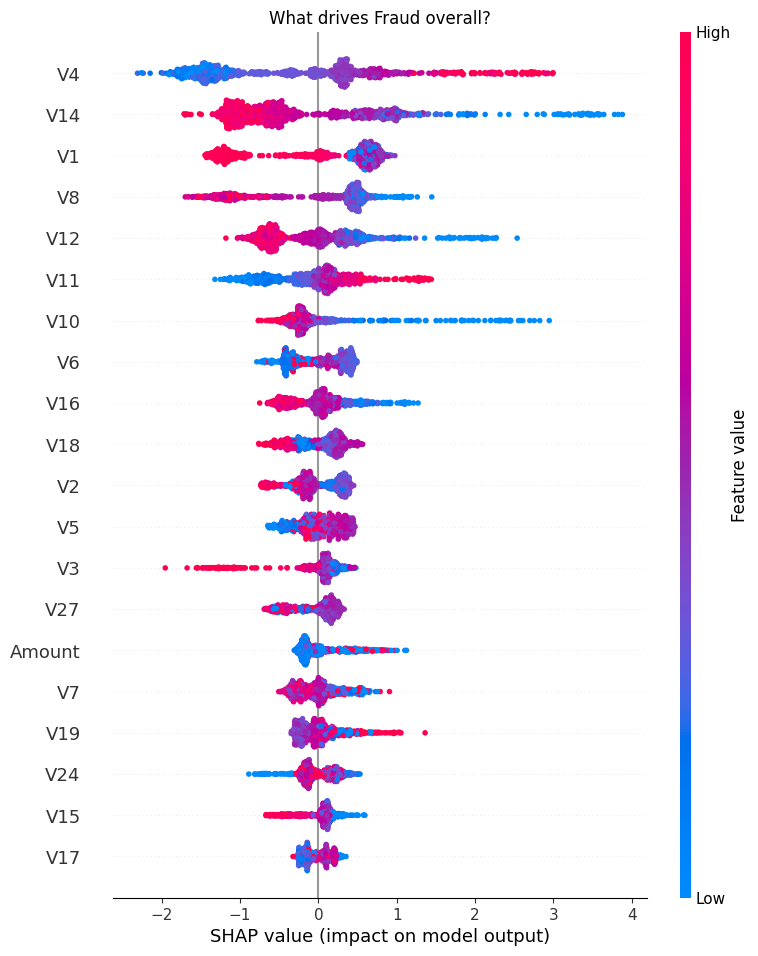

In [ ]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values.values, X_sample, show=False)
plt.title("What drives Fraud overall?")
plt.show()

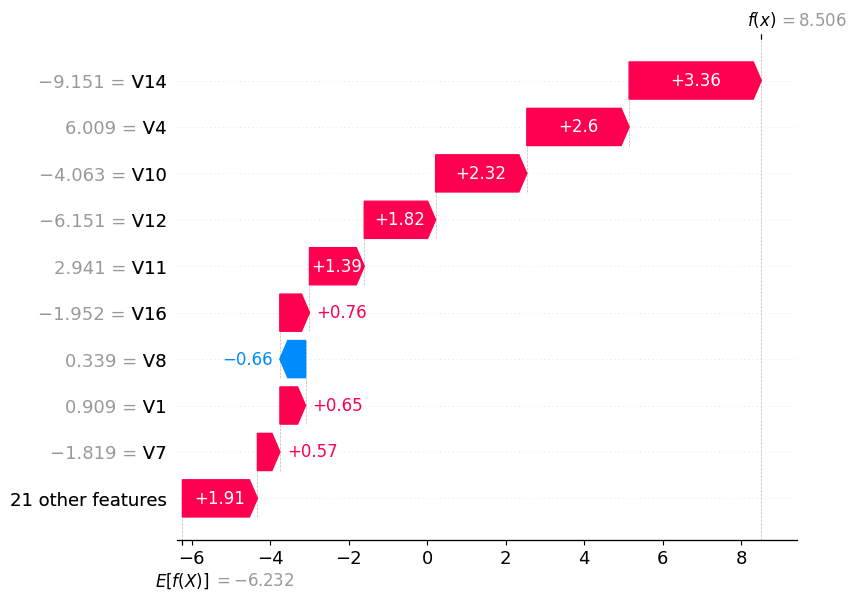

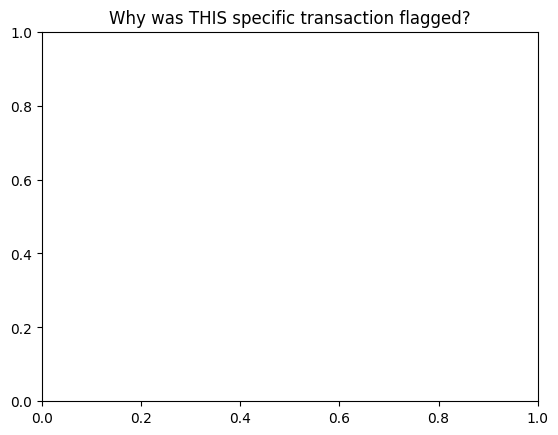

In [ ]:
first_fraud_row = np.where(y_sample == 1)[0][0] 

plt.figure(figsize=(8, 5))
shap.plots.waterfall(shap_values[first_fraud_row], max_display=10)
plt.title("Why was THIS specific transaction flagged?")
plt.show()

Classification Report on Unseen Test Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28459
           1       0.76      0.73      0.74        22

    accuracy                           1.00     28481
   macro avg       0.88      0.86      0.87     28481
weighted avg       1.00      1.00      1.00     28481



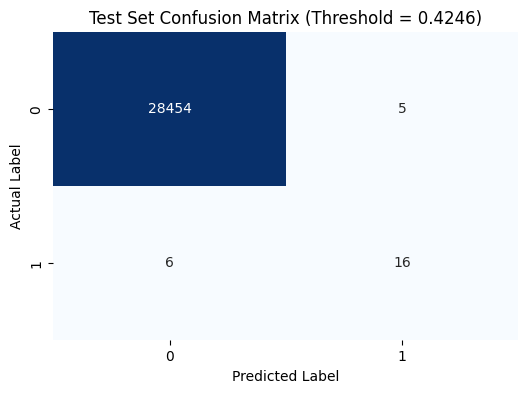

In [ ]:
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import sys, os
sys.path.append(os.path.abspath('..'))

import src.preprocessing as pp
from src.config import SETTINGS

df = pp.load_data("../" + SETTINGS['paths']['raw_data'])
_, _, X_test, _, _, y_test = pp.split_time_chronological(
    df, 
    train_size=SETTINGS['train_params']['train_size'], 
    val_size=SETTINGS['train_params']['val_size']
)

pipeline = joblib.load("../" + SETTINGS['paths']['model_output'])

y_test_probs = pipeline.predict_proba(X_test)[:, 1]

OPTIMAL_THRESHOLD = 0.1751
y_test_pred = (y_test_probs >= OPTIMAL_THRESHOLD).astype(int)

print("Classification Report on Unseen Test Set:")
print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Test Set Confusion Matrix (Threshold = {OPTIMAL_THRESHOLD})')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()